# 08 — Final Integration and Evaluation

Project: E-Waste Profitability Prediction
Group: 2026-AI-14
Module: IT3091 — Machine Learning

Selections recorded before test evaluation:
- Profit regression: Random Forest, raw features.
- Profit-tier classification: Gradient Boosting, raw features.

All four frozen model families will be evaluated on the same
held-out test records. Test results will not be used to retune
models or change the pre-recorded selections.

Batch_Priority is a derived profit-tier proxy.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import json
import io
import re
import hashlib
import joblib
import sklearn

from pathlib import Path
from datetime import datetime, timezone
from google.colab import files

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

pd.set_option("display.max_columns", None)

OUT = Path("final_outputs")
OUT.mkdir(exist_ok=True)

print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.6.1


In [ ]:
uploaded = files.upload()

# Accept browser download suffixes such as " (1)".
def normalise_filename(name):
    return re.sub(
        r"\s*\(\d+\)(?=\.[^.]+$)",
        "",
        Path(name).name
    )

file_bytes = {}

for name, contents in uploaded.items():
    normalised = normalise_filename(name)

    if normalised in file_bytes:
        raise ValueError(
            f"Duplicate file selected: {normalised}"
        )

    file_bytes[normalised] = contents

required = [
    "train_features.csv",
    "test_features.csv",
    "feature_config.json",
    "04_model_summary.json",
    "05_model_summary.json",
    "06_model_summary.json",
    "07_model_summary.json",
    "04_linear_profit_pipeline.joblib",
    "04_logistic_priority_pipeline.joblib",
    "05_tree_profit_pipeline.joblib",
    "05_tree_priority_pipeline.joblib",
    "06_forest_profit_pipeline.joblib",
    "06_forest_priority_pipeline.joblib",
    "07_boosting_profit_pipeline.joblib",
    "07_boosting_priority_pipeline.joblib"
]

missing = [
    name for name in required
    if name not in file_bytes
]

assert not missing, f"Missing files: {missing}"

train_df = pd.read_csv(
    io.BytesIO(file_bytes["train_features.csv"])
)

test_df = pd.read_csv(
    io.BytesIO(file_bytes["test_features.csv"])
)

config = json.loads(
    file_bytes["feature_config.json"].decode("utf-8-sig")
)

summaries = {
    number: json.loads(
        file_bytes[f"{number}_model_summary.json"]
        .decode("utf-8-sig")
    )
    for number in ["04", "05", "06", "07"]
}

print("All files received.")
print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

Saving 07_boosting_priority_pipeline.joblib to 07_boosting_priority_pipeline (1).joblib
Saving 07_boosting_profit_pipeline.joblib to 07_boosting_profit_pipeline (1).joblib
Saving 07_model_summary.json to 07_model_summary.json
Saving 06_forest_profit_pipeline.joblib to 06_forest_profit_pipeline (1).joblib
Saving 06_forest_priority_pipeline.joblib to 06_forest_priority_pipeline (1).joblib
Saving 06_model_summary.json to 06_model_summary.json
Saving 05_tree_priority_pipeline.joblib to 05_tree_priority_pipeline (1).joblib
Saving 05_tree_profit_pipeline.joblib to 05_tree_profit_pipeline (1).joblib
Saving 05_model_summary.json to 05_model_summary.json
Saving 04_linear_profit_pipeline.joblib to 04_linear_profit_pipeline (1).joblib
Saving 04_logistic_priority_pipeline.joblib to 04_logistic_priority_pipeline (1).joblib
Saving 04_model_summary.json to 04_model_summary.json
Saving train_features.csv to train_features.csv
Saving test_features.csv to test_features.csv
Saving feature_config.json to 

In [ ]:
import pandas as pd
import json
import io
import re
from pathlib import Path
from google.colab import files

# Preserve files from earlier uploads.
if "file_bytes" not in globals():
    file_bytes = {}

def normalise_filename(name):
    return re.sub(
        r"\s*\(\d+\)(?=\.[^.]+$)",
        "",
        Path(name).name
    )

# Recover the most recent upload if available.
for name, contents in globals().get("uploaded", {}).items():
    file_bytes[normalise_filename(name)] = contents

required = [
    "train_features.csv",
    "test_features.csv",
    "feature_config.json",
    "04_model_summary.json",
    "05_model_summary.json",
    "06_model_summary.json",
    "07_model_summary.json",
    "04_linear_profit_pipeline.joblib",
    "04_logistic_priority_pipeline.joblib",
    "05_tree_profit_pipeline.joblib",
    "05_tree_priority_pipeline.joblib",
    "06_forest_profit_pipeline.joblib",
    "06_forest_priority_pipeline.joblib",
    "07_boosting_profit_pipeline.joblib",
    "07_boosting_priority_pipeline.joblib"
]

missing = [
    name for name in required
    if name not in file_bytes
]

if missing:
    print("Select these missing files:")
    for name in missing:
        print("-", name)

    additional_uploads = files.upload()

    for name, contents in additional_uploads.items():
        file_bytes[normalise_filename(name)] = contents

missing = [
    name for name in required
    if name not in file_bytes
]

if missing:
    print("\nStill missing:")
    for name in missing:
        print("-", name)

    raise ValueError(
        "Run this cell again and upload the remaining files."
    )

train_df = pd.read_csv(
    io.BytesIO(file_bytes["train_features.csv"])
)

test_df = pd.read_csv(
    io.BytesIO(file_bytes["test_features.csv"])
)

config = json.loads(
    file_bytes["feature_config.json"].decode("utf-8-sig")
)

summaries = {
    number: json.loads(
        file_bytes[f"{number}_model_summary.json"]
        .decode("utf-8-sig")
    )
    for number in ["04", "05", "06", "07"]
}

print("\nAll 15 required files received.")
print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)


All 15 required files received.
Training shape: (16000, 19)
Test shape: (4000, 19)


Dataset and model versions validate

In [ ]:
assert train_df.columns.tolist() == test_df.columns.tolist()
assert len(train_df) == 16000
assert len(test_df) == 4000

for dataset in [train_df, test_df]:
    assert dataset["device_id"].notna().all()
    assert dataset["device_id"].is_unique

    assert np.isfinite(
        dataset["total_profit_usd"].to_numpy(dtype=float)
    ).all()

assert set(train_df["device_id"]).isdisjoint(
    set(test_df["device_id"])
)

features = config["feature_columns"]

assert not set(features) & {
    "device_id",
    "item_name",
    "total_profit_usd",
    "Batch_Priority"
}

policy = config["priority_policy"]

def profit_tier(values):
    values = np.asarray(values, dtype=float)

    return np.where(
        values <= policy["low_cutoff_usd"],
        "Low",
        np.where(
            values <= policy["high_cutoff_usd"],
            "Medium",
            "High"
        )
    )

for dataset in [train_df, test_df]:
    assert np.array_equal(
        dataset["Batch_Priority"].to_numpy(),
        profit_tier(dataset["total_profit_usd"])
    ), "Priority labels do not match the saved policy."

for number, summary in summaries.items():
    assert summary["test_evaluated"] is False

    assert summary["sklearn_version"] == sklearn.__version__, (
        f"Notebook {number} used sklearn "
        f"{summary['sklearn_version']}; current version is "
        f"{sklearn.__version__}. Use the same version."
    )

print("Dataset, policy and version checks passed.")

Dataset, policy and version checks passed.


CV Comparison

In [ ]:
cv_comparison = pd.DataFrame([
    {
        "notebook": number,
        "regression_model": summary["regression_model"],
        "regression_features": summary["regression_feature_set"],
        "CV_MAE_USD": summary["regression_cv_mae_usd"],
        "classification_model": summary["classification_model"],
        "classification_features": (
            summary["classification_feature_set"]
        ),
        "CV_Macro_F1": summary["classification_cv_macro_f1"]
    }
    for number, summary in summaries.items()
])

display(cv_comparison)

cv_comparison.to_csv(
    OUT / "cv_model_comparison.csv",
    index=False
)

,notebook,regression_model,regression_features,CV_MAE_USD,classification_model,classification_features,CV_Macro_F1
0,04,LinearRegression,raw_only,1.989018,LogisticRegression,raw_only,0.975771
1,05,DecisionTreeRegressor,raw_only,0.339261,DecisionTreeClassifier,with_engineered,0.978937
2,06,RandomForestRegressor,raw_only,0.279303,RandomForestClassifier,raw_only,0.979871
3,07,GradientBoostingRegressor,raw_only,0.331479,GradientBoostingClassifier,raw_only,0.982945


election then Test and save

In [ ]:
assert min(
    summaries,
    key=lambda number: summaries[number]["regression_cv_mae_usd"]
) == "06"

assert max(
    summaries,
    key=lambda number: summaries[number]["classification_cv_macro_f1"]
) == "07"

assert summaries["06"]["regression_feature_set"] == "raw_only"
assert summaries["07"]["classification_feature_set"] == "raw_only"

selection = {
    "recorded_at_utc": datetime.now(timezone.utc).isoformat(),
    "selection_basis": "Training five-fold CV, before test evaluation",

    "regression": {
        "notebook": "06",
        "model": "RandomForestRegressor",
        "feature_set": "raw_only",
        "reason": "Lowest mean CV MAE among evaluated regressors"
    },

    "classification": {
        "notebook": "07",
        "model": "GradientBoostingClassifier",
        "feature_set": "raw_only",
        "reason": "Highest mean CV macro-F1 among evaluated classifiers"
    },

    "priority_meaning": "Derived profit-tier proxy",

    "test_csv_sha256": hashlib.sha256(
        file_bytes["test_features.csv"]
    ).hexdigest(),

    "model_sha256": {
        name: hashlib.sha256(contents).hexdigest()
        for name, contents in file_bytes.items()
        if name.endswith(".joblib")
    }
}

with open(OUT / "selection_before_test.json", "w") as file:
    json.dump(selection, file, indent=2)

print("Pre-test selection recorded.")
display(pd.DataFrame([
    selection["regression"],
    selection["classification"]
]))

Pre-test selection recorded.


,notebook,model,feature_set,reason
0,06,RandomForestRegressor,raw_only,Lowest mean CV MAE among evaluated regressors
1,07,GradientBoostingClassifier,raw_only,Highest mean CV macro-F1 among evaluated class...


Frozen pipelines load

In [ ]:
model_files = {
    "04": (
        "04_linear_profit_pipeline.joblib",
        "04_logistic_priority_pipeline.joblib"
    ),
    "05": (
        "05_tree_profit_pipeline.joblib",
        "05_tree_priority_pipeline.joblib"
    ),
    "06": (
        "06_forest_profit_pipeline.joblib",
        "06_forest_priority_pipeline.joblib"
    ),
    "07": (
        "07_boosting_profit_pipeline.joblib",
        "07_boosting_priority_pipeline.joblib"
    )
}

models = {}

for number, (reg_file, cls_file) in model_files.items():
    regression_model = joblib.load(
        io.BytesIO(file_bytes[reg_file])
    )

    classification_model = joblib.load(
        io.BytesIO(file_bytes[cls_file])
    )

    assert type(
        regression_model.named_steps["model"]
    ).__name__ == summaries[number]["regression_model"]

    assert type(
        classification_model.named_steps["model"]
    ).__name__ == summaries[number]["classification_model"]

    # Previous notebooks fitted the pipelines using X containing
    # all input columns; each ColumnTransformer selects its subset.
    for model in [regression_model, classification_model]:
        assert model.feature_names_in_.tolist() == features

    models[number] = {
        "regression": regression_model,
        "classification": classification_model
    }

print("All eight frozen pipelines loaded.")

All eight frozen pipelines loaded.


Evaluate from test dataset

In [ ]:
X_test = test_df[features].copy()

y_test_reg = test_df["total_profit_usd"].to_numpy()
y_test_cls = test_df["Batch_Priority"].to_numpy()

test_predictions = {}
test_rows = []

for number, pair in models.items():
    predicted_profit = pair["regression"].predict(X_test)
    predicted_priority = pair["classification"].predict(X_test)

    assert np.isfinite(predicted_profit).all()

    test_predictions[number] = {
        "profit": predicted_profit,
        "priority": predicted_priority
    }

    test_rows.append({
        "notebook": number,
        "regression_model": summaries[number]["regression_model"],

        "Test_MAE_USD": mean_absolute_error(
            y_test_reg, predicted_profit
        ),
        "Test_RMSE_USD": np.sqrt(
            mean_squared_error(y_test_reg, predicted_profit)
        ),
        "Test_R2": r2_score(
            y_test_reg, predicted_profit
        ),
        "Negative_Profit_Predictions": int(
            (predicted_profit < 0).sum()
        ),

        "classification_model": (
            summaries[number]["classification_model"]
        ),
        "Test_Macro_F1": f1_score(
            y_test_cls,
            predicted_priority,
            average="macro",
            zero_division=0
        ),
        "Test_Balanced_Accuracy": balanced_accuracy_score(
            y_test_cls, predicted_priority
        ),
        "Test_Accuracy": accuracy_score(
            y_test_cls, predicted_priority
        )
    })

test_comparison = pd.DataFrame(test_rows)

display(test_comparison)

test_comparison.to_csv(
    OUT / "held_out_test_comparison.csv",
    index=False
)

for number, predictions in test_predictions.items():
    result = test_df[
        ["device_id", "total_profit_usd", "Batch_Priority"]
    ].copy()

    result["predicted_profit_usd"] = predictions["profit"]
    result["predicted_priority"] = predictions["priority"]

    result.to_csv(
        OUT / f"{number}_test_predictions.csv",
        index=False
    )

,notebook,regression_model,Test_MAE_USD,Test_RMSE_USD,Test_R2,Negative_Profit_Predictions,classification_model,Test_Macro_F1,Test_Balanced_Accuracy,Test_Accuracy
0,04,LinearRegression,1.997019,3.201668,0.941020,616,LogisticRegression,0.977384,0.977376,0.97750
1,05,DecisionTreeRegressor,0.322698,0.697960,0.997197,0,DecisionTreeClassifier,0.981938,0.981932,0.98200
2,06,RandomForestRegressor,0.279727,0.581364,0.998055,0,RandomForestClassifier,0.982663,0.982654,0.98275
3,07,GradientBoostingRegressor,0.332096,0.600325,0.997926,0,GradientBoostingClassifier,0.986184,0.986180,0.98625


The models selected using training cross-validation also achieved the best held-out test performance for their respective tasks. Random Forest Regression achieved an MAE of USD 0.279727, RMSE of USD 0.581364, and R² of 0.998055, with no negative profit predictions. Its test MAE was close to its CV MAE of USD 0.279303. Gradient Boosting Classification achieved a macro-F1 of 0.986184, balanced accuracy of 0.986180, and accuracy of 98.625%, correctly classifying 3,945 of 4,000 test records. The classification target represents derived profit tiers rather than independently verified operational priorities. No models were retuned or selections changed using test results. Performance on this holdout does not establish generalisation to future periods or new suppliers.

Selected classifier report and confusion matrix

,precision,recall,f1-score,support
Low,0.985650,0.985650,0.985650,1324.00000
Medium,0.981032,0.977324,0.979175,1323.00000
High,0.991900,0.995565,0.993729,1353.00000
accuracy,0.986250,0.986250,0.986250,0.98625
macro avg,0.986194,0.986180,0.986184,4000.00000
weighted avg,0.986236,0.986250,0.986241,4000.00000


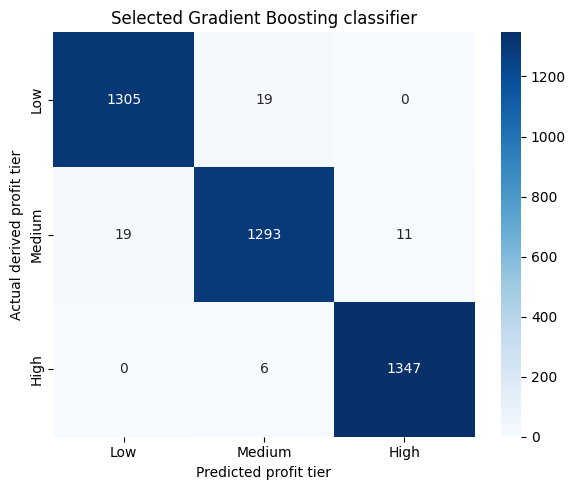

In [ ]:
selected_profit = test_predictions["06"]["profit"]
selected_priority = test_predictions["07"]["priority"]

report = pd.DataFrame(
    classification_report(
        y_test_cls,
        selected_priority,
        labels=["Low", "Medium", "High"],
        output_dict=True,
        zero_division=0
    )
).T

display(report)

report.to_csv(
    OUT / "selected_classifier_report.csv"
)

labels = ["Low", "Medium", "High"]

matrix = confusion_matrix(
    y_test_cls,
    selected_priority,
    labels=labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted profit tier")
plt.ylabel("Actual derived profit tier")
plt.title("Selected Gradient Boosting classifier")
plt.tight_layout()

plt.savefig(
    OUT / "selected_confusion_matrix.png",
    dpi=150
)

plt.show()

The selected Gradient Boosting classifier achieved its strongest class-level performance for the High profit tier, with precision of 99.190%, recall of 99.557%, and an F1-score of 0.993729. It correctly identified 1,347 of 1,353 actual High-tier records, missing six. Eleven records from other tiers were incorrectly predicted as High. The Medium tier had the lowest recall (97.732%) and F1-score (0.979175), with 30 misclassified records. Overall, 55 of 4,000 records were misclassified. These classes represent derived profit tiers, so the results do not validate independent operational priority.

Selected regressor failure cases

In [ ]:
final_results = test_df.copy()

final_results["predicted_profit_usd"] = selected_profit
final_results["predicted_priority"] = selected_priority

final_results["residual_usd"] = (
    final_results["total_profit_usd"] -
    final_results["predicted_profit_usd"]
)

final_results["absolute_error_usd"] = (
    final_results["residual_usd"].abs()
)

failure_cases = final_results.nlargest(
    20,
    "absolute_error_usd"
)

display(
    failure_cases[
        [
            "device_id",
            "device_category",
            "condition",
            "total_profit_usd",
            "predicted_profit_usd",
            "absolute_error_usd"
        ]
    ]
)

category_errors = (
    final_results.groupby("device_category")
    ["absolute_error_usd"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

display(category_errors)

failure_cases.to_csv(
    OUT / "selected_regression_failure_cases.csv",
    index=False
)

category_errors.to_csv(
    OUT / "selected_error_by_category.csv"
)

classification_failures = final_results.loc[
    final_results["Batch_Priority"] !=
    final_results["predicted_priority"]
]

classification_failures.to_csv(
    OUT / "selected_classification_failure_cases.csv",
    index=False
)

,device_id,device_category,condition,total_profit_usd,predicted_profit_usd,absolute_error_usd
3475,DEV-09694,Desktop Motherboard,New,61.22,56.180876,5.039124
1674,DEV-01863,Desktop Motherboard,New,61.34,56.490169,4.849831
2996,DEV-12386,Desktop Motherboard,Refurbished,56.93,61.747653,4.817653
3890,DEV-09005,Desktop Motherboard,Refurbished,68.95,73.531393,4.581393
3463,DEV-13109,Laptop,Refurbished,41.64,37.774172,3.865828
3067,DEV-05227,Desktop Motherboard,New,85.70,89.419875,3.719875
2360,DEV-05355,Desktop Motherboard,Used-Good,43.54,47.216287,3.676287
1682,DEV-08765,Desktop Motherboard,Used-Fair,50.84,47.206480,3.633520
2367,DEV-12444,Desktop Motherboard,New,43.89,47.505586,3.615586
1147,DEV-15468,Desktop Motherboard,Refurbished,62.42,65.962534,3.542534


,count,mean,median,max
device_category,,,,
Desktop Motherboard,404,1.142232,0.947514,5.039124
Laptop,428,0.715594,0.635714,3.865828
Microprocessor,395,0.459163,0.355229,1.965989
Tablet,403,0.113758,0.101259,0.551828
Digital Camera,391,0.098118,0.083896,0.539960
Hard Disk Drive,376,0.070547,0.057545,0.316760
Smartphone,377,0.053604,0.043342,0.261268
Wi-Fi Router,400,0.041404,0.032329,0.182893
RAM Module,415,0.039059,0.033192,0.225388


The selected Random Forest regressor had the highest category-level test MAE for Desktop Motherboards (USD 1.1422), followed by Laptops (USD 0.7156) and Microprocessors (USD 0.4592). Eighteen of the twenty largest absolute errors involved Desktop Motherboards, while two involved Laptops. The largest error was USD 5.0391 for DEV-09694, whose recorded profit of USD 61.22 was underestimated as USD 56.18. Higher recorded profit values may partly explain the larger dollar errors, but this requires further analysis. These findings support closer human review of motherboard and laptop estimates.

Selected regressor feature importance

In [ ]:
from sklearn.inspection import permutation_importance

selected_regressor = models["06"]["regression"]

regression_features = summaries["06"]["regression_features"]

importance = permutation_importance(
    selected_regressor,
    X_test[regression_features],
    y_test_reg,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=2
)

importance_table = pd.DataFrame({
    "feature": regression_features,
    "MAE_increase_USD": importance.importances_mean,
    "STD_MAE_increase_USD": importance.importances_std
}).sort_values("MAE_increase_USD", ascending=False)

display(importance_table)

importance_table.to_csv(
    OUT / "selected_regression_permutation_importance.csv",
    index=False
)

,feature,MAE_increase_USD,STD_MAE_increase_USD
2,gold_yield_g,11.034607,0.175032
7,condition,2.298596,0.059678
3,silver_yield_g,0.160604,0.001638
4,copper_yield_g,0.116443,0.002648
5,Acquisition_Cost_LKR,0.058412,0.002059
0,weight_g,0.034010,0.001360
6,device_category,0.023115,0.001150
1,device_age_years,0.000666,0.001262
8,Hazardous_Flag,-0.000219,0.000346
9,Casing_Material,-0.001108,0.000431


Test-set permutation importance showed that the selected Random Forest regressor relied most strongly on gold yield and device condition. Shuffling gold yield increased MAE by USD 11.034607, while shuffling condition increased MAE by USD 2.298596. Silver and copper yields had smaller positive importance values. Device age, hazardous flag, and casing material showed little predictive contribution in this evaluation. These values describe model reliance rather than causal effects or operational safety importance. Correlated inputs may affect the rankings. No features were removed or models retrained using these test-set findings.

Profit prediction සහ tier output consistency

In [ ]:
final_results["tier_from_predicted_profit"] = profit_tier(
    selected_profit
)

final_results["tier_disagreement"] = (
    final_results["tier_from_predicted_profit"] !=
    final_results["predicted_priority"]
)

print(
    "Output tier disagreements:",
    int(final_results["tier_disagreement"].sum())
)

print(
    "Disagreement percentage:",
    round(
        final_results["tier_disagreement"].mean() * 100,
        2
    )
)

display(
    final_results.loc[
        final_results["tier_disagreement"],
        [
            "device_id",
            "predicted_profit_usd",
            "tier_from_predicted_profit",
            "predicted_priority"
        ]
    ].head(10)
)

Output tier disagreements: 28
Disagreement percentage: 0.7


,device_id,predicted_profit_usd,tier_from_predicted_profit,predicted_priority
292,DEV-15085,1.578508,Medium,Low
324,DEV-14013,1.572092,Medium,Low
380,DEV-18685,1.616141,Medium,Low
426,DEV-12788,4.647800,Medium,High
436,DEV-07182,4.676591,Medium,High
551,DEV-03169,1.575322,Medium,Low
743,DEV-10677,1.604854,Medium,Low
864,DEV-15245,1.564947,Low,Medium
1368,DEV-01163,1.544798,Low,Medium
1420,DEV-02899,4.967444,High,Medium


The selected Random Forest regressor and Gradient Boosting classifier produced consistent profit-tier outputs for 3,972 of 4,000 test records (99.3%). For 28 records (0.7%), the tier derived from predicted profit differed from the classifier’s predicted tier. The displayed examples were close to tier boundaries, although all disagreements require inspection before generalising this observation. Agreement measures output consistency rather than predictive accuracy. Both predictions should be retained, with disagreements flagged for human review.

Final models and metadata save

In [ ]:
joblib.dump(
    models["06"]["regression"],
    OUT / "final_profit_pipeline.joblib"
)

joblib.dump(
    models["07"]["classification"],
    OUT / "final_priority_pipeline.joblib"
)

with open(OUT / "feature_config.json", "w") as file:
    json.dump(config, file, indent=2)

final_metadata = {
    "selection": selection,
    "selected_regression_test_results": (
        test_comparison.loc[
            test_comparison["notebook"] == "06"
        ].iloc[0].to_dict()
    ),
    "selected_classification_test_results": (
        test_comparison.loc[
            test_comparison["notebook"] == "07"
        ].iloc[0].to_dict()
    ),
    "test_evaluated": True,
    "sklearn_version": sklearn.__version__,
    "tier_disagreement_count": int(
        final_results["tier_disagreement"].sum()
    ),
    "priority_meaning": "Derived profit-tier proxy",
    "models_retuned_after_test": False
}

with open(OUT / "final_model_metadata.json", "w") as file:
    json.dump(final_metadata, file, indent=2)

print("Final models, evaluation and metadata saved.")

Final models, evaluation and metadata saved.


Final interpretation and recommendation

## Final evaluation
- CV-selected models:
- Selected regression test MAE, RMSE and R²:
- Selected classification test macro-F1 and balanced accuracy:
- CV versus test differences:
- High-tier recall and important classification errors:
- High-error categories and regression failure cases:
- Profit/tier output disagreements:

## Stakeholder recommendation
Use recorded-profit estimates and profit-tier predictions as
decision support with human review.

Review uncertain measurements, hazardous items, unusual inputs
and disagreements between profit estimates and tier predictions.

## Limitations
- Metal-yield availability before purchasing needs confirmation.
- The accounting definition of recorded profit needs verification.
- Operational time, energy and contamination measurements are absent.
- Priority labels are derived from profit, not independent
  operational ground truth.
- Classification CV is conditional on the training-derived policy.
- Random holdout does not validate new suppliers or future periods.
- Predictions do not establish a verified maximum purchase price.

## Industry Explorer evidence
Add verified data provenance, permission, scope approval and
feedback from the same stakeholder. Do not invent evidence.

## AI-use transparency and contributions
Record actual assistance, verification and each member's work.

Models and evidence download

In [ ]:
download_names = [
    "cv_model_comparison.csv",
    "selection_before_test.json",
    "held_out_test_comparison.csv",
    "selected_classifier_report.csv",
    "selected_regression_failure_cases.csv",
    "selected_error_by_category.csv",
    "selected_regression_permutation_importance.csv",
    "final_profit_pipeline.joblib",
    "final_priority_pipeline.joblib",
    "feature_config.json",
    "final_model_metadata.json"
]

for name in download_names:
    files.download(str(OUT / name))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
train_df.to_csv(
    OUT / "final_train_features.csv",
    index=False
)

test_df.to_csv(
    OUT / "final_test_features.csv",
    index=False
)

final_results.to_csv(
    OUT / "final_test_predictions.csv",
    index=False
)

files.download(str(OUT / "final_train_features.csv"))
files.download(str(OUT / "final_test_features.csv"))
files.download(str(OUT / "final_test_predictions.csv"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The models selected using training cross-validation also achieved the best held-out test performance for their respective tasks. Random Forest Regression achieved an MAE of USD 0.279727, RMSE of USD 0.581364, and R² of 0.998055, with no negative profit predictions. Its test MAE was close to its CV MAE of USD 0.279303. Gradient Boosting Classification achieved a macro-F1 of 0.986184, balanced accuracy of 0.986180, and accuracy of 98.625%, correctly classifying 3,945 of 4,000 test records. The classification target represents derived profit tiers rather than independently verified operational priorities. No models were retuned or selections changed using test results. Performance on this holdout does not establish generalisation to future periods or new suppliers.

In [ ]:
import shutil
from google.colab import files

train_df.to_csv(OUT / "final_train_features.csv", index=False)
test_df.to_csv(OUT / "final_test_features.csv", index=False)
final_results.to_csv(OUT / "final_test_predictions.csv", index=False)

zip_path = shutil.make_archive(
    "08_Final_Outputs",
    "zip",
    root_dir=str(OUT)
)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>